# Bug and Corrections notebook 

## Imports 

In [1]:
import pandas as pd
import logging
import sys
import numpy as np
from dataclasses import asdict
from pathlib import Path

sys.path.append(r"C:\Users\giuli\Repositories\intraday-momentum\src")
path = "/home/corwyn/Black_swan/Intraday_project/intraday-momentum"
sys.path.append("/home/corwyn/Black_swan/Intraday_project/intraday-momentum/src")
from classes.metrics.metrics import MetricsCalculator
from classes.backtest.engine import BacktestEngine  
from classes.backtest.default import BacktestDefaults 

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True,   # <-- allow printing in jupyter notebooks
)

logger = logging.getLogger(__name__)


In [2]:
root = path

df_spy = pd.read_pickle(root + "/data/cleaned/intraday_sp500.pkl")
df_dividends = pd.read_csv(root + "/data/cleaned/SPY_dividends_2022-05-09_2024-04-22.csv")
df_spy_daily = pd.read_pickle(root + "/data/cleaned/daily_sp500.pkl")

# Print information about the dataframes
df_spy.info()
print("\n")
df_dividends.info()
print("\n")
df_spy_daily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 36754 entries, 2023-12-06 14:30:00+00:00 to 2024-04-22 20:00:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   volume  36754 non-null  float64
 1   open    36754 non-null  float64
 2   high    36754 non-null  float64
 3   low     36754 non-null  float64
 4   close   36754 non-null  float64
dtypes: float64(5)
memory usage: 1.7 MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cash_amount       8 non-null      float64
 1   currency          8 non-null      object 
 2   declaration_date  8 non-null      object 
 3   dividend_type     8 non-null      object 
 4   ex_dividend_date  8 non-null      object 
 5   frequency         8 non-null      int64  
 6   id                8 non-null      object 
 7   pay_date       

In [3]:
dfs = {
    "df_spy": df_spy,
    "df_spy_daily": df_spy_daily,
}

for name, df in dfs.items():
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(f"{name}: index must be a DatetimeIndex.")
    else:
        logger.info(f"{name}: index is a valid DatetimeIndex with timezone={df.index.tz}.")


2025-12-10 17:12:51,725 | INFO | df_spy: index is a valid DatetimeIndex with timezone=UTC.
2025-12-10 17:12:51,726 | INFO | df_spy_daily: index is a valid DatetimeIndex with timezone=UTC.


### Dividends

In [4]:
# Make a copy
df_dividends_prepared = df_dividends.copy()

# Rename columns to match what MetricsCalculator expects
df_dividends_prepared = df_dividends_prepared.rename(columns={
    "ex_dividend_date": "caldt",  # Metrics expects 'caldt'
    "cash_amount": "dividend"     # Metrics expects 'dividend'
})

# Convert 'caldt' to datetime
df_dividends_prepared["caldt"] = pd.to_datetime(df_dividends_prepared["caldt"])

# Keep only the necessary columns
df_dividends_prepared = df_dividends_prepared[["caldt", "dividend", "ticker"]]

# Verify
print(df_dividends_prepared.head())
print(df_dividends_prepared.columns)

       caldt  dividend ticker
0 2023-12-15  1.906073    SPY
1 2023-09-15  1.583169    SPY
2 2023-06-16  1.638367    SPY
3 2023-03-17  1.506204    SPY
4 2024-12-20  1.965548    SPY
Index(['caldt', 'dividend', 'ticker'], dtype='object')


### Metrics

In [5]:
mc = MetricsCalculator()
df_spy, df_spy_daily = mc.from_clean_df(df_spy, df_dividends_prepared)
mc.quality_check(df_spy, df_spy_daily)
mc.logger.info("All SPY metrics successfully computed.")

2025-12-10 17:12:51,786 | INFO | Starting computation of market microstructure metrics...
2025-12-10 17:12:52,557 | INFO | Running quality checks...
2025-12-10 17:12:52,563 | INFO | NaN summary:
log_returns    1
RV             0
BV             0
vwap           0
price          0
day            0
dtype: int64
2025-12-10 17:12:52,564 | INFO | df_all_days shape: (36754, 21)
2025-12-10 17:12:52,565 | INFO | df_daily_profiles shape: (36754, 22)
2025-12-10 17:12:52,614 | INFO | df_all saved to data/processed/df_all_days.pkl
2025-12-10 17:12:52,669 | INFO | df_daily saved to data/processed/df_daily_groups.pkl
2025-12-10 17:12:52,670 | INFO | Running quality checks...
2025-12-10 17:12:52,674 | INFO | NaN summary:
log_returns    1
RV             0
BV             0
vwap           0
price          0
day            0
dtype: int64
2025-12-10 17:12:52,675 | INFO | df_all_days shape: (36754, 21)
2025-12-10 17:12:52,675 | INFO | df_daily_profiles shape: (36754, 22)
2025-12-10 17:12:52,676 | INFO | All

In [10]:
import pandas as pd

# Example if your index is already datetime
if not "timestamp" in df_spy.columns:
    df_spy = df_spy.copy()
    if isinstance(df_spy.index, pd.DatetimeIndex):
        df_spy["timestamp"] = df_spy.index
    else:
        # If you have a column with the datetime, rename it
        df_spy["timestamp"] = pd.to_datetime(df_spy["your_datetime_column_here"])

# Create a 'day' column
df_spy["day"] = df_spy["timestamp"].dt.date

# Check
print(df_spy.tail())


                      timestamp     volume     open     high      low  \
36749 2024-04-22 19:56:00+00:00   610685.0  499.350  499.530  499.305   
36750 2024-04-22 19:57:00+00:00   469276.0  499.445  499.445  499.160   
36751 2024-04-22 19:58:00+00:00   942709.0  499.250  499.250  498.905   
36752 2024-04-22 19:59:00+00:00  2630731.0  499.020  499.700  499.010   
36753 2024-04-22 20:00:00+00:00   362284.0  499.630  499.730  499.000   

         close         day  log_returns        RV        BV  ...        vwap  \
36749  499.450  2024-04-22     0.000200  0.008334  0.000029  ...  498.863819   
36750  499.245  2024-04-22    -0.000411  0.008334  0.000029  ...  498.867361   
36751  499.015  2024-04-22    -0.000461  0.008334  0.000029  ...  498.870519   
36752  499.630  2024-04-22     0.001232  0.008334  0.000029  ...  498.896142   
36753  499.190  2024-04-22    -0.000881  0.008334  0.000029  ...  498.898641   

              hlc  move_open  spy_dvol   spy_ret  min_from_open  \
36749  499.42

### Backtests

In [7]:

defaults = BacktestDefaults(
    minute_path=path + "/notebooks/data/processed/df_all_days.pkl",
    daily_path= path + "/notebooks/data/processed/df_daily_groups.pkl",
    initial_aum=100_000.0,
    commission_rate=0.0035,
    min_comm_per_order=0.35,
    slippage_bps=0,
    band_mult=1.0,
    trade_freq=30,
    sizing_type="vol_target",
    target_vol=0.02,
    max_leverage=4.0, #Warning should be 2.0 in Quantconnect
)

engine = BacktestEngine()
trade_log_df, daily_pnl_df, equity_curve_df = engine.run_backtest(asdict(defaults))

[WARNING] Daily data at '/home/corwyn/Black_swan/Intraday_project/intraday-momentum/notebooks/data/processed/df_daily_groups.pkl' is missing required columns: 'caldt' and/or 'close'.


2025-12-10 17:12:53,269 | INFO | Trade log saved to /home/corwyn/Black_swan/Intraday_project/intraday-momentum/src/data/processed/trade_log.csv
2025-12-10 17:12:53,270 | INFO | Daily PnL saved to /home/corwyn/Black_swan/Intraday_project/intraday-momentum/src/data/processed/daily_pnl.pkl


2025-12-10 17:12:55,335 | INFO | Dataframe correctly initialized
2025-12-10 17:12:55,337 | INFO | Computing comulative AUM for SPY
2025-12-10 17:12:55,559 | ERROR | Failed to save plot to /home/corwyn/Black_swan/Intraday_project/intraday-momentum/ouputs/figures/test_01.jpg: [Errno 2] No such file or directory: '/home/corwyn/Black_swan/Intraday_project/intraday-momentum/ouputs/figures/test_01.jpg'


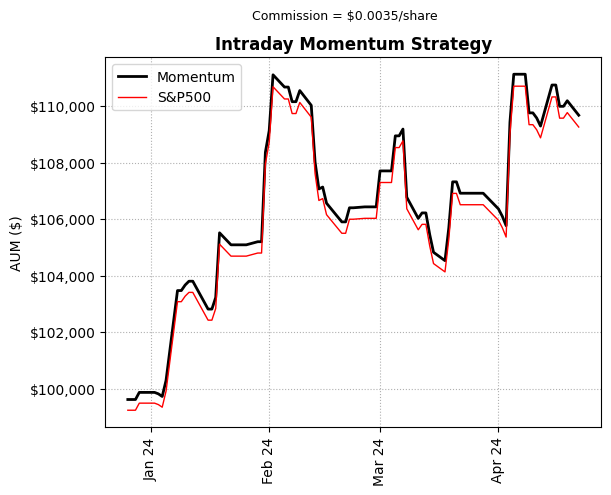

In [8]:
from classes.viz.plotter import Plotter
df = pd.read_pickle(path + "/src/data/processed/daily_pnl.pkl")
df.index = pd.to_datetime(df.index)
plott = Plotter(df)
# Use actual starting AUM to avoid ValueError
start_aum = df["AUM"].iloc[0]
plott.plot_cum_returns("ret", "AUM",path + "/ouputs/figures/test_01.jpg", AUM_0=start_aum)

In [9]:
plott.compute_statistics("ret", "AUM", 0.000107 )

2025-12-10 17:12:55,693 | INFO | Computing returns and performance statistics such as Sharpe, Hit, Drawdown)


,Total Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Hit Ratio (%),Maximum Drawdown (%)
Value,10.0,33.3,14.4,1.88,49.0,6.0
